In [1]:
import sys

from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from configuration import (
    SAMPLE_RATE, HOP_LENGTH, N_FFT, N_MELS, BATCH_SIZE,
    VAE_CKPT_PATH, OUTPUT_DIR, device,
)
from dataset.mel_dataset import MelDataset, trim_to_shape
from dataset.create_chunks import iter_chunks
from models import VAE

FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR  = OUTPUT_DIR / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MUSDB_ROOT = Path('../musdb18/musdb18_mixtures')
CHUNK_DURATION = 10
N_TEST_SONGS   = None

print('device:', device)

/home/matej/Documents/DIPLRAD/music_gen_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:

vae = VAE().to(device)
ckpt = torch.load(VAE_CKPT_PATH, map_location=device)
vae.load_state_dict(ckpt['model_state'])
vae.eval()
print('Loaded VAE from', VAE_CKPT_PATH)

Loaded VAE from ../musdb18/output/vae_checkpoint.pt


In [3]:
test_files = list(iter_chunks(MUSDB_ROOT, 'test', CHUNK_DURATION, N_TEST_SONGS))
print(f'Test chunks: {len(test_files)}')
if len(test_files) == 0:
    raise FileNotFoundError(f'No test chunks found under {MUSDB_ROOT}/test. '
                            'Run dataset/create_chunks.py first.')

test_ds     = MelDataset(test_files)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Test chunks: 1223


In [4]:
def mel_to_audio_np(mel_01: np.ndarray) -> np.ndarray:
    mel_db    = mel_01 * 80.0 - 80.0
    mel_power = librosa.db_to_power(mel_db)
    return librosa.feature.inverse.mel_to_audio(
        mel_power, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
    )


def spectral_centroid_mean(mel_01: np.ndarray) -> float:
    audio = mel_to_audio_np(mel_01)
    sc    = librosa.feature.spectral_centroid(y=audio, sr=SAMPLE_RATE, n_fft=N_FFT,
                                              hop_length=HOP_LENGTH)
    return float(sc.mean())


def log_spectral_distance(mel_orig: np.ndarray, mel_recon: np.ndarray) -> float:
    eps = 1e-8
    S_orig  = librosa.db_to_power(mel_orig  * 80.0 - 80.0)
    S_recon = librosa.db_to_power(mel_recon * 80.0 - 80.0)
    lsd = np.sqrt(np.mean((np.log10(S_orig + eps) - np.log10(S_recon + eps)) ** 2))
    return float(lsd)

In [5]:
l1_errors    = []
lsd_scores   = []
sc_orig_list = []
sc_recon_list= []

vis_originals  = []
vis_recons     = []
N_VIS = 4

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating VAE on test set'):
        x = batch.to(device)                         # (B, 1, H, W)
        x_hat, mu, logvar = vae(x)
        x_hat = trim_to_shape(x_hat, x.shape[-2:])

        for i in range(x.size(0)):
            orig_np  = x[i, 0].cpu().numpy()
            recon_np = x_hat[i, 0].cpu().numpy()

            l1_errors.append(float(np.abs(orig_np - recon_np).mean()))
            lsd_scores.append(log_spectral_distance(orig_np, recon_np))

            if len(vis_originals) < N_VIS:
                vis_originals.append(orig_np)
                vis_recons.append(recon_np)

SC_SUBSET = min(50, len(vis_originals) * 5, len(test_ds))
print(f'Computing spectral centroid on {SC_SUBSET} clips...')
sc_subset_ds     = MelDataset(test_files[:SC_SUBSET])
sc_subset_loader = DataLoader(sc_subset_ds, batch_size=4, shuffle=False, num_workers=0)

with torch.no_grad():
    for batch in tqdm(sc_subset_loader, desc='Spectral centroid', leave=False):
        x = batch.to(device)
        x_hat, _, _ = vae(x)
        x_hat = trim_to_shape(x_hat, x.shape[-2:])
        for i in range(x.size(0)):
            sc_orig_list.append(spectral_centroid_mean(x[i, 0].cpu().numpy()))
            sc_recon_list.append(spectral_centroid_mean(x_hat[i, 0].cpu().numpy()))

print(f'Evaluated {len(l1_errors)} clips')

Evaluating VAE on test set: 100%|██████████| 153/153 [00:32<00:00,  4.65it/s]


Computing spectral centroid on 20 clips...


Evaluated 1223 clips


In [6]:
l1_arr  = np.array(l1_errors)
lsd_arr = np.array(lsd_scores)
sc_diff = np.abs(np.array(sc_orig_list) - np.array(sc_recon_list))

print('=' * 55)
print('VAE Reconstruction Metrics — Test Set')
print('=' * 55)
print(f'  Clips evaluated        : {len(l1_arr)}')
print(f'  L1 error   mean ± std  : {l1_arr.mean():.4f} ± {l1_arr.std():.4f}')
print(f'  L1 error   median      : {np.median(l1_arr):.4f}')
print(f'  LSD        mean ± std  : {lsd_arr.mean():.4f} ± {lsd_arr.std():.4f}')
print(f'  SC diff    mean ± std  : {sc_diff.mean():.1f} ± {sc_diff.std():.1f} Hz')
print('=' * 55)

VAE Reconstruction Metrics — Test Set
  Clips evaluated        : 1223
  L1 error   mean ± std  : 0.0452 ± 0.0085
  L1 error   median      : 0.0441
  LSD        mean ± std  : 0.4678 ± 0.0817
  SC diff    mean ± std  : 30.5 ± 21.3 Hz


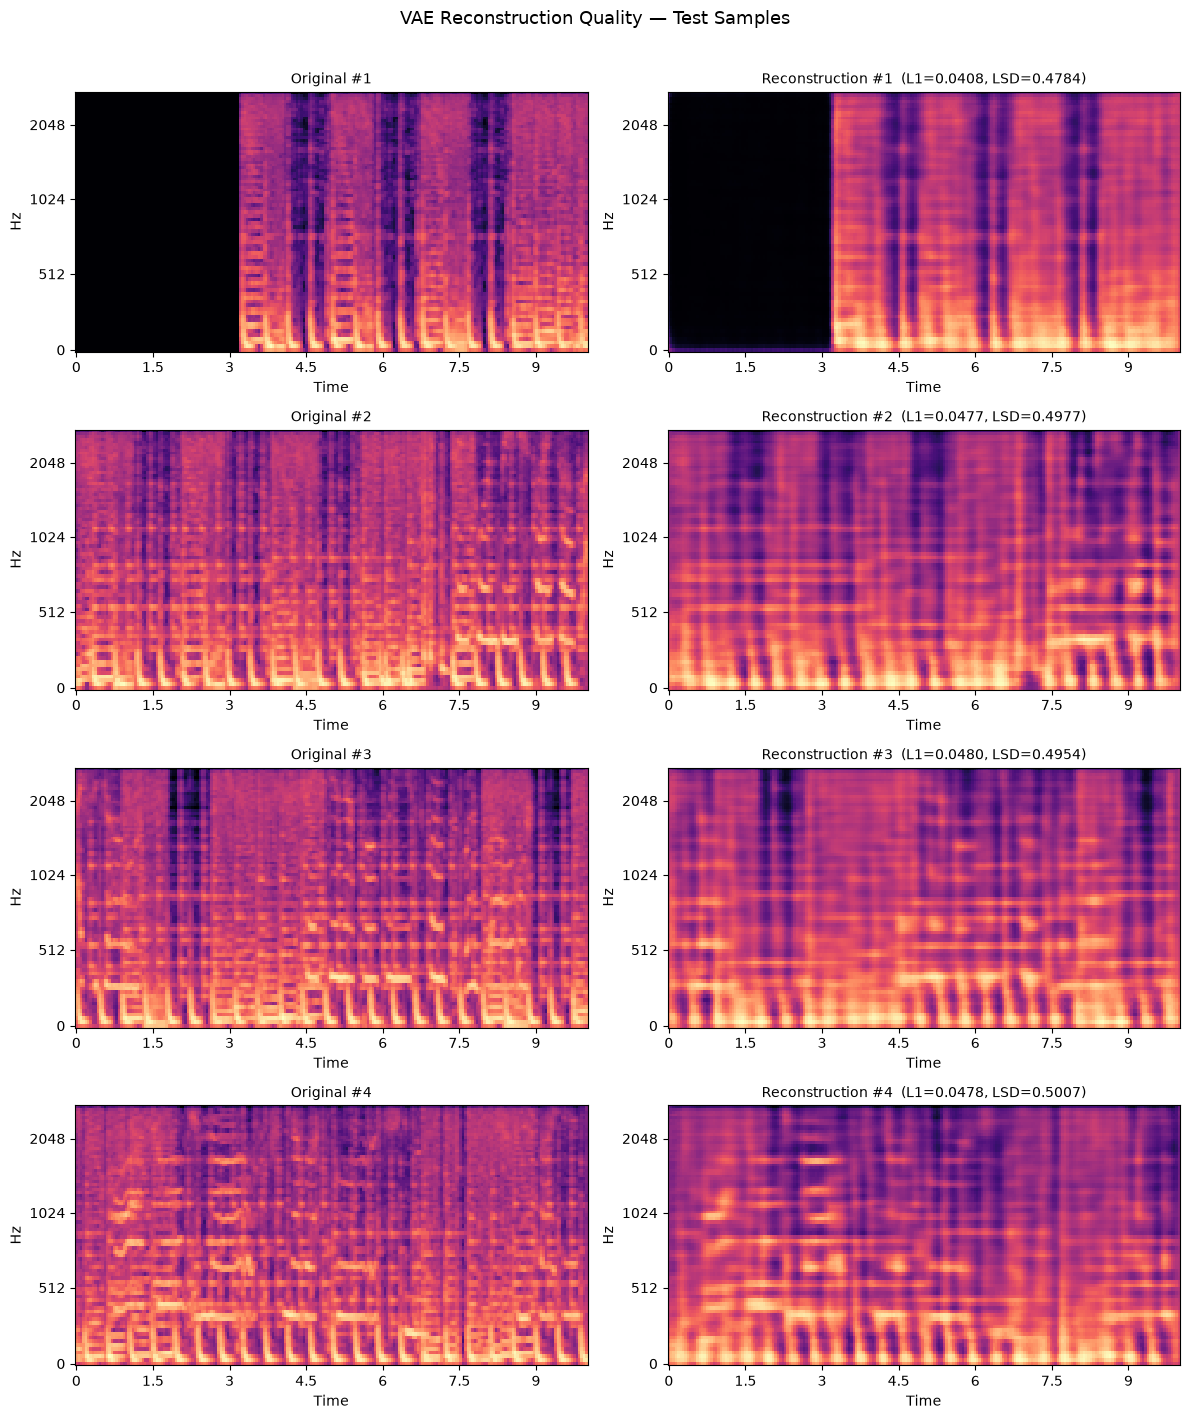

Saved: ../musdb18/output/figures/vae_recon_comparison.png


In [7]:
n_pairs = len(vis_originals)
fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 3.5 * n_pairs))
if n_pairs == 1:
    axes = np.array([axes])

for i, (orig_np, recon_np) in enumerate(zip(vis_originals, vis_recons)):
    db_orig  = orig_np  * 80.0 - 80.0
    db_recon = recon_np * 80.0 - 80.0

    librosa.display.specshow(db_orig,  sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i, 0])
    axes[i, 0].set_title(f'Original #{i+1}', fontsize=10)

    librosa.display.specshow(db_recon, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(
        f'Reconstruction #{i+1}  (L1={l1_errors[i]:.4f}, LSD={lsd_scores[i]:.4f})',
        fontsize=10)

plt.suptitle('VAE Reconstruction Quality — Test Samples', fontsize=13, y=1.01)
plt.tight_layout()
out_path = FIGURES_DIR / 'vae_recon_comparison.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

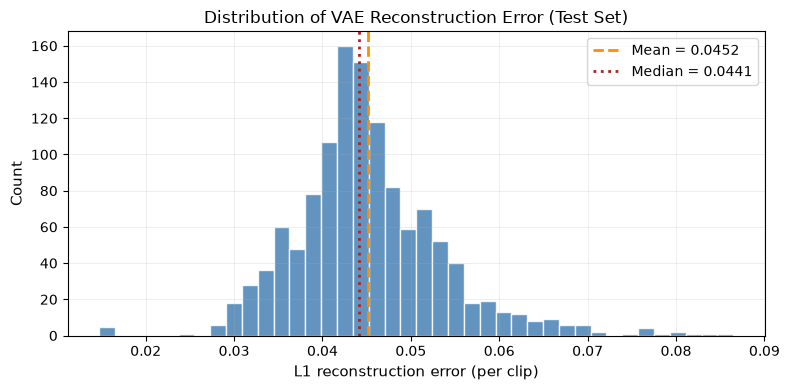

Saved: ../musdb18/output/figures/vae_l1_histogram.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(l1_arr, bins=40, edgecolor='white', color='steelblue', alpha=0.85)
ax.axvline(l1_arr.mean(),   color='darkorange', linewidth=2, linestyle='--',
           label=f'Mean = {l1_arr.mean():.4f}')
ax.axvline(np.median(l1_arr), color='firebrick', linewidth=2, linestyle=':',
           label=f'Median = {np.median(l1_arr):.4f}')
ax.set_xlabel('L1 reconstruction error (per clip)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of VAE Reconstruction Error (Test Set)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = FIGURES_DIR / 'vae_l1_histogram.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)